# 多次元正規分布の例（p.46 図4.7(b)） 

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using LinearAlgebra
using Distributions
using CairoMakie # Plots, StatsPlots, gr() から置き換え

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 多次元正規分布関数の定義

In [2]:
# 正規分布関数の定義
function N_multi(x, μ, Σ, d)
    # 多次元分布正規関数
    # μ : 平均ベクトル
    # Σ : 共分散行列
    # d : 次元数
    # 指数部はマハラノビス距離を表す

    N = (1 / ((2π)^(d/2) * det(Σ)^(1/2))) * exp(-(1/2) * transpose(x - μ) * inv(Σ) * (x-μ))
    
    # det() : 行列式（LinearAlgebraが必要）、行列計算なのでabs()ではなくこちらを使う
    # abs() : 絶対値←今回は使わない
    # exp() : 指数関数
    # transpose() : 行列の転置
    # inv() : 逆行列

    return N[1] # 行列演算の結果は1×1行列になるので[1]でスカラーとして返す

end


N_multi (generic function with 1 method)

### 2. 2次元正規分布関数のパラメーター設定
- $\mu$ と $\Sigma$ はp.47の例示をそのまま使用。

In [3]:
# パラメーター
d = 2   # 2次元正規分布
μ = [2; 1] # μはp.47の例示のママ。 [2 1]' （転置）で書くと行列扱いで型判定エラーになる。μ = [2, 1]でも可
Σ = [0.7068966 0.5172414;
0.5172414 1.7931034]    # Σはp.47の例示のママ

2×2 Matrix{Float64}:
 0.706897  0.517241
 0.517241  1.7931

### 3. 等高線の描画

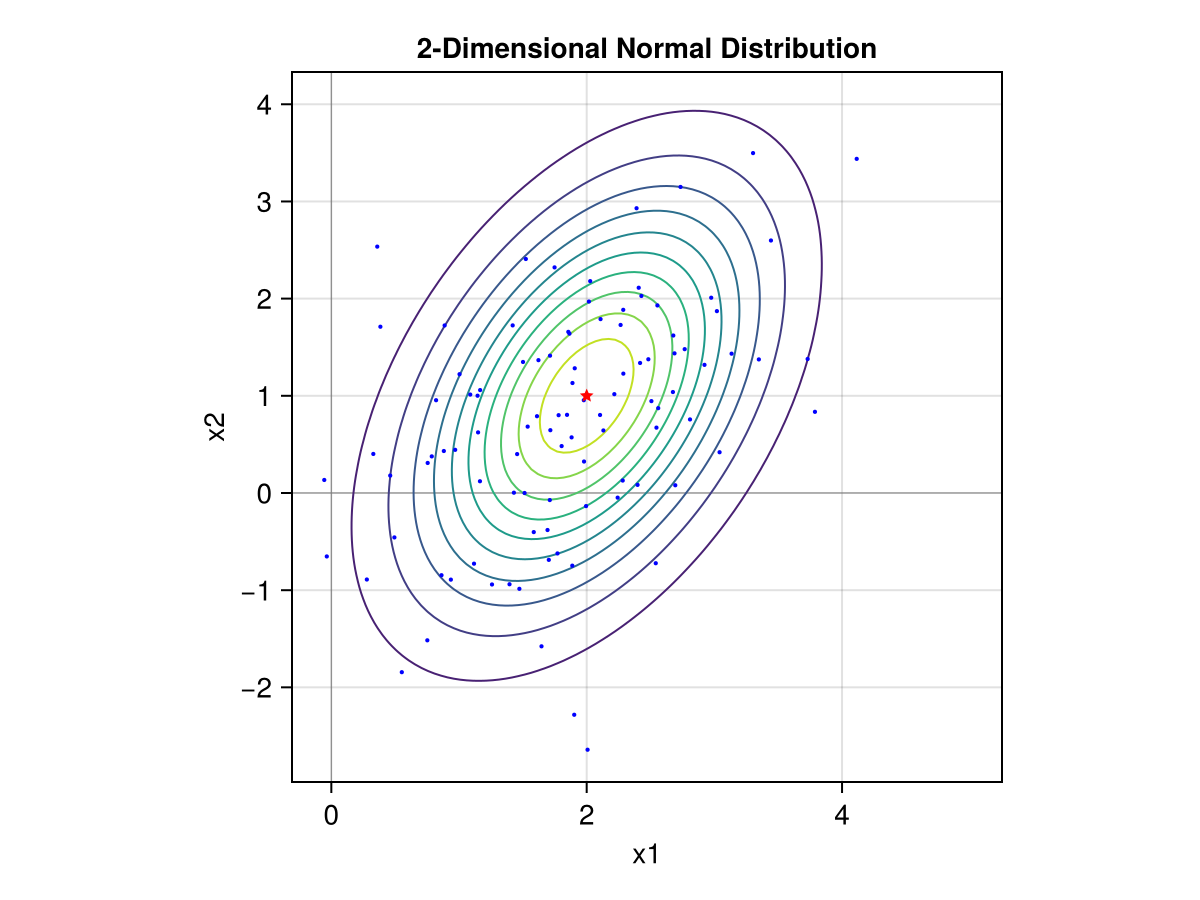

In [4]:
# (1)CairoMakieの設定
# Figure() で外枠、Axis() でグラフの軸（タイトルやラベル）を作成
fig = Figure(size = (600, 450))
ax = Axis(fig[1, 1], 
    title = "2-Dimensional Normal Distribution",
    xlabel = "x1", 
    ylabel = "x2",
    # aspect = DataAspect() # アスペクト比をデータの単位に合わせる
    aspect = 1 # アスペクト比を1:1にする
)
vlines!(ax, [0.0], color=:gray50, linewidth = 0.5) # x1=0の点線
hlines!(ax, [0.0], color=:gray50, linewidth = 0.5) # x2=0の点線

# (2)描画データの準備
# xとyの範囲を指定してグリッドを作成
x1_grid = range(0.0, 5.0, length=100)
x2_grid = range(-2.0, 4.0, length=100)

# 全グリッドに対して2次元正規分布関数N_multiを用いて高さの行列zsを計算
zs = [N_multi([x1, x2], μ, Σ, d) for x1 in x1_grid, x2 in x2_grid]  # ⚠Plotsのcontourはy軸とx軸の与え方が逆になる

# (3)等高線を描画
contour!(ax, x1_grid, x2_grid, zs,
    levels=10, # 等高線のレベル数
    colormap=:viridis,
    colorrange=(0, maximum(zs)) # カラーマップの範囲をデータの最大値に合わせる
)

# (4)100個のサンプルデータを準備
# (A)単純に乱数でサンプルデータを作成する
xv = [(rand(), rand()) for _ in 1:100]
xv_x1 = [x[1] for x in xv]  # 各xvの第1要素抽出
xv_x2 = [x[2] for x in xv]  # 各xvの第2要素抽出

# (B)正規分布に従う点を作成する
dist = MultivariateNormal(μ, Σ)
data = rand(dist, 100)  # 2行100列の行列を生成

xv_x1 = data[1, :]
xv_x2 = data[2, :]

# (5)サンプルデータを散布図で描画
scatter!(ax, xv_x1, xv_x2,
    label="Samples",
    markersize=3,
    color=:blue
)

# (6)平均をプロット
scatter!(ax, [μ[1]], [μ[2]],
    label="mean μ",
    marker=:star5,
    markersize=8,
    color=:red
)

# (7)グラフの保存と表示
save("pima_02_multivariate_normal_distribution.png", fig) # 保存
fig # 表示


- `CairoMakie`使用
- `CairoMakie`と`Plots`では`contour`のx軸とy軸のデータを渡す順番が逆になっている点に注意。